# 12 — Radical Equations; Equations Quadratic in Form; Factorable Equations

**Equations and Inequalities ▸ 4.** So far we can solve **linear** and **quadratic**
equations. Today we grow this toolbox to a much bigger family, using **three tricks**:

1. **Radical equations** — the unknown sits *inside a root*, e.g. $\sqrt{x+2}=x$. We undo
   the root by **raising both sides to a power**. But squaring is a one-way door: it can
   create fake answers, so we must **check every solution**.
2. **Equations quadratic in form** — the equation is *not* a quadratic, but it *looks* like
   one after a smart **substitution**, e.g. $x^4-13x^2+36=0$ becomes $u^2-13u+36=0$ with
   $u=x^2$. We solve the easy quadratic, then translate back.
3. **Factorable equations** — higher-degree equations we crack by **factoring** and then
   setting each factor to zero (the Zero Product Property from topic 5).

The single most important new idea is the **extraneous solution**: a value that appears
during solving but does **not** actually satisfy the original equation. It sneaks in when
we do a step that is *not reversible* (like squaring). The habit to build today:
**solve, then CHECK in the original equation.**

**Why it matters for AI.** Trick #2 is your first taste of **change of variables** — pick
new coordinates $u=g(x)$ in which a hard problem becomes an easy one. That single idea runs
through calculus ($u$-substitution), the **kernel trick** in machine learning (map data to
a space where a curved boundary becomes a straight/quadratic one), and feature engineering.
And "check your candidate answer against the real constraint" is exactly how we **validate**
a model instead of trusting the math blindly.

## Quick recall (spaced repetition)
From session 11 (Complex Numbers). Solutions at the **end of §1**.

1. Solve $x^2 + 2x + 5 = 0$ over $\mathbb{C}$ (use the quadratic formula).
2. **(new weak spot)** Simplify $\sqrt{-4}\cdot\sqrt{-9}$. Careful — what is the rule?
3. Powers of $i$: what is $i^{23}$?

## What we cover today
1. **Radical equations**; why squaring makes **extraneous** roots; the check step (proved).
2. Equations with **two radicals** (isolate, square, isolate, square).
3. **Equations quadratic in form**: the substitution method (justified).
4. **Factorable equations**: grouping + Zero Product Property for higher degree.
5. Python: `sympy.solve`/`solveset`, a hand-written **extraneous-solution checker**,
   `numpy` roots, and plots that *show* which crossings are real.

## 1. Definitions

> **Definition (radical equation).** A **radical equation** is an equation in which the
> unknown $x$ appears **underneath a root sign** (a radical), such as $\sqrt{x+2}=x$ or
> $\sqrt[3]{2x-1}=3$. The **index** of the radical is the little number $n$ in $\sqrt[n]{\ }$
> ($n=2$ for a square root).

> **Definition (extraneous solution).** When solving an equation we often replace it by a
> new equation using some operation (e.g. squaring both sides). A number that satisfies the
> **new** equation but **not** the **original** one is called an **extraneous solution** — a
> "false" root the operation introduced. It must be **rejected**.

> **Definition (equation quadratic in form).** An equation is **quadratic in form** if a
> substitution $u = g(x)$ turns it into a genuine quadratic $a u^2 + b u + c = 0$. Typical
> shapes: $x^4+bx^2+c=0$ ($u=x^2$), $x-b\sqrt{x}+c=0$ ($u=\sqrt x$),
> $x^{2/3}+bx^{1/3}+c=0$ ($u=x^{1/3}$), or $(\text{expr})^2+b(\text{expr})+c=0$
> ($u=\text{expr}$).

> **Definition (factorable equation).** A polynomial (or similar) equation $p(x)=0$ that we
> solve by writing $p$ as a product of simpler factors and setting each factor to zero.

The engine behind all of this is one fact you already proved:

> **Zero Product Property (topic 5).** In a field, $AB=0 \iff A=0 \text{ or } B=0.$
> More generally $A_1A_2\cdots A_k=0 \iff$ at least one $A_j=0$.

## 2. Theorems with full proofs

### Theorem 1 (raising to a power is safe forward, but only *odd* powers are reversible)
Let $A$ and $B$ be real expressions and $n\ge 1$ an integer.

**(a) Forward direction is always valid.** If $A = B$, then $A^n = B^n$. Therefore
**every** solution of the equation $A=B$ is also a solution of $A^n=B^n$. (So we never
*lose* solutions by raising to a power.)

**(b) Odd $n$: no extraneous solutions.** If $n$ is odd, then $A^n=B^n \iff A=B$. So
raising to an odd power creates no fake roots.

**(c) Even $n$: extraneous solutions possible.** If $n$ is even, $A^n=B^n$ only gives
$A=\pm B$. Solutions with $A=-B$ (but $A\ne B$) are extraneous.

**Proof.** (a) Equality means $A$ and $B$ are the *same number*; the same number raised to
the $n$-th power gives the same result. Formally, the function $t\mapsto t^n$ is a function,
so equal inputs give equal outputs.

(b) The map $f(t)=t^n$ for **odd** $n$ is **strictly increasing** on all of $\mathbb{R}$
(proved in topic 8, Lemma A style: if $s<t$ then $s^n<t^n$ for odd $n$, including across
$0$ because odd powers keep sign). A strictly increasing function is **one-to-one**:
different inputs give different outputs. Hence $A^n=B^n \Rightarrow A=B$, and the converse
is (a). So $\iff$.

(c) For **even** $n$, $f(t)=t^n$ is **not** one-to-one: $f(-t)=(-t)^n=t^n=f(t)$. From
$A^n=B^n$ we get $A^n-B^n=0$. Factor the even case through the square:
$A^n-B^n=(A^{n/2})^2-(B^{n/2})^2=(A^{n/2}-B^{n/2})(A^{n/2}+B^{n/2})$, so
$A^{n/2}=\pm B^{n/2}$; peeling roots gives $A=\pm B$. The branch $A=-B$ can hold **without**
$A=B$ (unless $A=B=0$), and those extra values are exactly the extraneous ones. $\qquad\blacksquare$

> **Consequence — the golden rule of radical equations.** Isolate the radical, raise both
> sides to the index power, solve, and **substitute every candidate back into the ORIGINAL
> equation**. Keep only the ones that truly work. For **even** index ($\sqrt{\ }$, $\sqrt[4]{\ }$)
> this check is *mandatory*; for **odd** index ($\sqrt[3]{\ }$) it is a safe habit but no
> root will be lost or faked.

Where do the fakes come from? A square root symbol $\sqrt{\ }$ means the **non-negative**
root. So $\sqrt{x+2}=x$ secretly demands $x\ge 0$. Squaring throws that sign information
away, so a negative candidate can slip through — and the check catches it.

### Theorem 2 (the substitution principle for "quadratic in form")
Let $g$ be any function and suppose an equation can be written as
$$ a\,\big(g(x)\big)^2 + b\,g(x) + c = 0, \qquad a\ne 0. $$
Let $u_1,u_2$ be the (real or complex) roots of the quadratic $au^2+bu+c=0$. Then the
solution set of the original equation is
$$ \{\, x : g(x)=u_1 \,\}\ \cup\ \{\, x : g(x)=u_2 \,\}. $$
That is: **solve the quadratic in $u$, then solve $g(x)=u_j$ for each root $u_j$** — and
keep only $x$ that lie in the domain of the original equation.

**Proof.** Put $u=g(x)$. For a fixed $x$, the number $u$ is determined, and the original
left-hand side equals $au^2+bu+c$. So $x$ solves the original equation
$\iff$ $au^2+bu+c=0$ with $u=g(x)$ $\iff$ $g(x)\in\{u_1,u_2\}$ (because $u_1,u_2$ are
*exactly* the numbers making the quadratic zero — Zero Product Property applied to
$a(u-u_1)(u-u_2)=0$). This is the stated union. $\qquad\blacksquare$

**Warning.** The back-substitution $g(x)=u_j$ can itself be a radical or fractional
equation, so it may bring its **own** domain limits or extraneous roots. Example: with
$u=\sqrt x$ we need $u\ge 0$, so a **negative** root $u_j$ gives **no** $x$. Always finish
by checking against the original.

### Theorem 3 (factor $\Rightarrow$ solve, for any degree)
If a polynomial factors as $p(x)=a(x-r_1)(x-r_2)\cdots(x-r_k)\,q(x)$ where $q$ has no real
roots, then the real solutions of $p(x)=0$ are exactly $r_1,\dots,r_k$.

**Proof.** By the Zero Product Property (topic 5), $p(x)=0$ iff one of the factors is $0$.
Each $x-r_j=0$ gives $x=r_j$; the factor $q(x)$ is never $0$ for real $x$ by assumption, and
the constant $a\ne 0$ is never $0$. So the real solution set is $\{r_1,\dots,r_k\}$. (Over
$\mathbb{C}$, the Fundamental Theorem of Algebra from topic 11 says $q$ also factors, so
*every* root is caught.) $\qquad\blacksquare$

### Recall-quiz solutions (from the top)
1. $x=\dfrac{-2\pm\sqrt{4-20}}{2}=\dfrac{-2\pm\sqrt{-16}}{2}=\dfrac{-2\pm 4i}{2}=-1\pm 2i$.
2. Convert first: $\sqrt{-4}\,\sqrt{-9}=(2i)(3i)=6i^2=-6$ — **not** $\sqrt{36}=6$. Never
   merge two negative radicals under one root.
3. $i^{23}=i^{4\cdot5+3}=i^3=-i$.

## 3. Worked examples

**Example A — a radical with an extraneous root.** Solve $\sqrt{x+2}=x$.
Square both sides: $x+2=x^2$, i.e. $x^2-x-2=0=(x-2)(x+1)$, so $x=2$ or $x=-1$.
**Check in the original:**
- $x=2$: $\sqrt{4}=2$ ✓.
- $x=-1$: $\sqrt{1}=1$, but the right side is $-1$. $1\ne-1$ ✗ — **extraneous**, reject.

Answer: $x=2$ only. (The fake root $-1$ came from squaring away the sign, exactly Theorem 1c.)

**Example B — two radicals.** Solve $\sqrt{2x+3}-\sqrt{x+1}=1$.
Isolate one radical: $\sqrt{2x+3}=1+\sqrt{x+1}$. Square:
$2x+3 = 1 + 2\sqrt{x+1} + (x+1)$, so $x+1 = 2\sqrt{x+1}$. Isolate and square again:
$(x+1)^2 = 4(x+1)$, i.e. $(x+1)(x+1-4)=0$, so $x=-1$ or $x=3$.
**Check:** $x=3$: $\sqrt9-\sqrt4=3-2=1$ ✓. $x=-1$: $\sqrt1-\sqrt0=1-0=1$ ✓.
Both work — answer $x\in\{-1,3\}$.

**Example C — quadratic in form ($u=x^2$).** Solve $x^4-13x^2+36=0$.
Let $u=x^2$: $u^2-13u+36=0=(u-4)(u-9)$, so $u=4$ or $u=9$. Back-substitute:
$x^2=4\Rightarrow x=\pm2$; $x^2=9\Rightarrow x=\pm3$. Four solutions: $\pm2,\pm3$.

**Example D — quadratic in form ($u=\sqrt x$).** Solve $x-5\sqrt x+6=0$.
Note $x=(\sqrt x)^2$, so with $u=\sqrt x\ (\ge0)$: $u^2-5u+6=0=(u-2)(u-3)$, $u=2$ or $u=3$.
Both are $\ge0$, good. Back-substitute: $\sqrt x=2\Rightarrow x=4$; $\sqrt x=3\Rightarrow x=9$.
**Check:** $4-5(2)+6=0$ ✓, $9-5(3)+6=0$ ✓. Answer $\{4,9\}$.
(If a $u$-root had been negative, it would give **no** $x$, since $\sqrt x\ge0$.)

**Example E — factor by grouping.** Solve $x^3-4x^2-x+4=0$.
Group: $x^2(x-4)-(x-4)=(x-4)(x^2-1)=(x-4)(x-1)(x+1)=0$. So $x\in\{4,1,-1\}$.

**Example F — hidden common factor (don't divide by $x$!).** Solve $x^3=9x$.
Bring to one side: $x^3-9x=0$, factor $x(x^2-9)=x(x-3)(x+3)=0$, so $x\in\{0,3,-3\}$.
If you had *divided* by $x$ you would lose $x=0$ — the same trap as in topic 10.

## 4. Python demonstrations

We use `sympy` to solve **symbolically** and to *automatically drop extraneous roots*, and
we also write our **own checker** so you can see the extraneous root appear and get
rejected — that is the real lesson of this topic.

In [1]:
import sympy as sp

x = sp.symbols('x', real=True)   # ask for real solutions

# Example A: sqrt(x+2) = x.  sympy's solve already removes extraneous roots.
solA = sp.solve(sp.Eq(sp.sqrt(x + 2), x), x)
print("Example A  sqrt(x+2)=x  ->", solA)      # [2]  (the fake root -1 is dropped)

# See the extraneous root by solving the SQUARED equation instead:
solA_sq = sp.solve(sp.Eq(x + 2, x**2), x)
print("squared version x+2=x^2 ->", solA_sq)   # [-1, 2]  <- -1 is extraneous

Example A  sqrt(x+2)=x  -> [2]
squared version x+2=x^2 -> [-1, 2]


In [2]:
# A reusable extraneous-solution CHECKER: substitute each candidate back into the
# ORIGINAL equation and keep only those that truly satisfy it.
import sympy as sp
x = sp.symbols('x')

def keep_valid(lhs, rhs, candidates):
    """Return the candidates that actually satisfy lhs = rhs (real, exact check)."""
    good = []
    for c in candidates:
        # substitute x = c on both sides and simplify the difference to test equality
        diff = sp.simplify(lhs.subs(x, c) - rhs.subs(x, c))
        ok = (diff == 0)
        print(f"  x = {c}:  LHS={sp.nsimplify(lhs.subs(x,c))}, RHS={sp.nsimplify(rhs.subs(x,c))}  -> {'keep' if ok else 'EXTRANEOUS'}")
        if ok:
            good.append(c)
    return good

lhs, rhs = sp.sqrt(x + 2), x
print("Checking candidates [-1, 2] against the ORIGINAL sqrt(x+2)=x:")
print("valid ->", keep_valid(lhs, rhs, [-1, 2]))

Checking candidates [-1, 2] against the ORIGINAL sqrt(x+2)=x:
  x = -1:  LHS=1, RHS=-1  -> EXTRANEOUS
  x = 2:  LHS=2, RHS=2  -> keep
valid -> [2]


In [3]:
# Example B: two radicals.  sqrt(2x+3) - sqrt(x+1) = 1
import sympy as sp
x = sp.symbols('x', real=True)
solB = sp.solve(sp.Eq(sp.sqrt(2*x + 3) - sp.sqrt(x + 1), 1), x)
print("Example B ->", solB)          # [-1, 3]  (both are valid here)

Example B -> [-1, 3]


In [4]:
# Example C & D: quadratic-in-form, solved BY SUBSTITUTION (Theorem 2), step by step.
import sympy as sp
x, u = sp.symbols('x u')

# C: x^4 - 13x^2 + 36 = 0 with u = x^2
u_roots = sp.solve(u**2 - 13*u + 36, u)            # solve the easy quadratic in u
print("C: u-roots (u=x^2):", u_roots)              # [4, 9]
x_roots = []
for ur in u_roots:
    x_roots += sp.solve(sp.Eq(x**2, ur), x)        # back-substitute x^2 = u
print("C: x-roots:", sorted(x_roots, key=lambda t: float(t)))   # [-3,-2,2,3]

# D: x - 5*sqrt(x) + 6 = 0 with u = sqrt(x) >= 0
u_roots = sp.solve(u**2 - 5*u + 6, u)              # [2, 3], both >= 0
print("D: u-roots (u=sqrt x):", u_roots)
x_roots = [ur**2 for ur in u_roots if ur >= 0]     # sqrt(x)=u -> x=u^2, need u>=0
print("D: x-roots:", x_roots)                      # [4, 9]

C: u-roots (u=x^2): [4, 9]
C: x-roots: [-3, -2, 2, 3]
D: u-roots (u=sqrt x): [2, 3]
D: x-roots: [4, 9]


In [5]:
# Example E & F: factorable higher-degree equations.
import sympy as sp
x = sp.symbols('x')
print("E: x^3-4x^2-x+4=0 ->", sp.solve(x**3 - 4*x**2 - x + 4, x))   # [-1, 1, 4]
print("   factored:", sp.factor(x**3 - 4*x**2 - x + 4))
print("F: x^3 = 9x     ->", sp.solve(sp.Eq(x**3, 9*x), x))          # [-3, 0, 3] (0 kept!)

E: x^3-4x^2-x+4=0 -> [-1, 1, 4]
   factored: (x - 4)*(x - 1)*(x + 1)
F: x^3 = 9x     -> [-3, 0, 3]


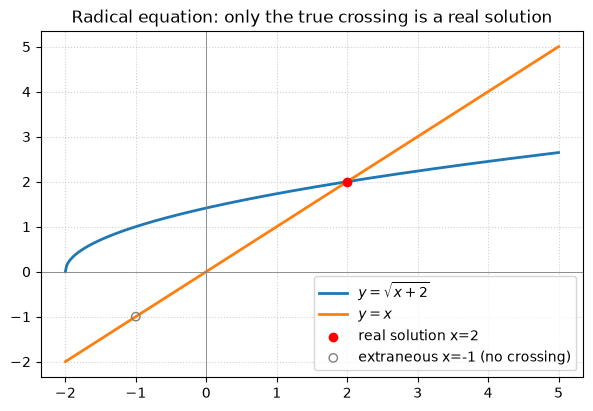

In [6]:
# SEE it: plot y = sqrt(x+2) and y = x. A real solution is where the curves CROSS.
import numpy as np
import matplotlib.pyplot as plt

xs = np.linspace(-2, 5, 400)              # domain of sqrt(x+2) starts at x = -2
plt.figure(figsize=(7, 4.5))
plt.plot(xs, np.sqrt(xs + 2), label=r'$y=\sqrt{x+2}$', lw=2)
plt.plot(xs, xs, label=r'$y=x$', lw=2)
plt.scatter([2], [2], color='red', zorder=5, label='real solution x=2')
# the algebra also produced x=-1, but there the line y=x is BELOW the curve -> no crossing
plt.scatter([-1], [-1], facecolors='none', edgecolors='gray', zorder=5,
            label='extraneous x=-1 (no crossing)')
plt.axhline(0, color='gray', lw=0.6); plt.axvline(0, color='gray', lw=0.6)
plt.legend(); plt.grid(True, ls=':', alpha=0.6)
plt.title('Radical equation: only the true crossing is a real solution')
plt.show()

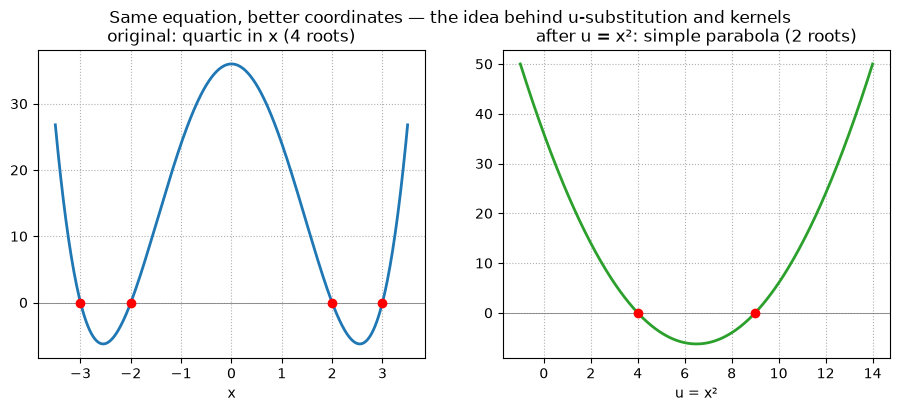

In [7]:
# AI HOOK: change of variables makes a hard curve simple.
# x^4 - 13x^2 + 36 is a wiggly quartic in x, but with u = x^2 it is a plain parabola in u.
import numpy as np
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

xs = np.linspace(-3.5, 3.5, 400)
ax1.plot(xs, xs**4 - 13*xs**2 + 36, lw=2)
ax1.axhline(0, color='gray', lw=0.6)
for r in [-3, -2, 2, 3]:
    ax1.scatter([r], [0], color='red', zorder=5)
ax1.set_title('original: quartic in x (4 roots)'); ax1.set_xlabel('x'); ax1.grid(True, ls=':')

us = np.linspace(-1, 14, 400)
ax2.plot(us, us**2 - 13*us + 36, lw=2, color='tab:green')
ax2.axhline(0, color='gray', lw=0.6)
for r in [4, 9]:
    ax2.scatter([r], [0], color='red', zorder=5)
ax2.set_title('after u = x²: simple parabola (2 roots)'); ax2.set_xlabel('u = x²'); ax2.grid(True, ls=':')
plt.suptitle('Same equation, better coordinates — the idea behind u-substitution and kernels')
plt.show()

## 5. Exercises (fill in the cells yourself)

Solve by hand first, **always checking candidates in the original equation**, then verify
with `sympy`. Easy $\to$ hard; the last few are proofs.

**Radical equations (check for extraneous!)**
1. $\sqrt{x} = 7$.
2. $\sqrt{3x-2} = 4$.
3. $\sqrt[3]{2x+1} = 3$ (odd index — does it need a check?).
4. $\sqrt{x+7} = x+1$.
5. $\sqrt{2x+3} = x$.
6. $x - \sqrt{x+5} = 1$ (isolate the radical first).

**Two radicals**
7. $\sqrt{x+1} + \sqrt{x-2} = 3$.
8. $\sqrt{3x+1} - \sqrt{x+4} = 1$.

**Quadratic in form (state your substitution $u=g(x)$ every time)**
9. $x^4 - 5x^2 + 4 = 0$.
10. $x - 6\sqrt{x} + 8 = 0$.
11. $x^{2/3} - x^{1/3} - 6 = 0$  (let $u=x^{1/3}$).
12. $\dfrac{1}{x^2} - \dfrac{1}{x} - 12 = 0$  (let $u = \tfrac1x$).
13. $(x^2 - x)^2 - 8(x^2 - x) + 12 = 0$  (let $u = x^2 - x$).
14. $2x^4 + x^2 - 15 = 0$  (watch for complex roots from the $u<0$ branch — topic 11).

**Factorable equations**
15. $x^3 - x = 0$.
16. $x^3 + 2x^2 - 9x - 18 = 0$ (factor by grouping).
17. $x^4 - 16 = 0$ (give all real **and** complex roots — topic 11).

**Proofs / reasoning**
18. **Explain**, using Theorem 1, why solving $\sqrt{x+2}=x$ can produce the extraneous root
    $x=-1$, but solving $\sqrt[3]{x+2}=x$ never produces an extraneous root.
19. **Prove:** if $\sqrt{f(x)}=g(x)$ has a solution $x_0$, then necessarily $g(x_0)\ge 0$.
    (This one inequality is *why* the check works.) Use it to reject a root in one line.
20. **Prove** the substitution principle (Theorem 2) in your own words for the specific case
    $x^4+bx^2+c=0$ with $u=x^2$: show every solution of the quartic gives a root of
    $u^2+bu+c=0$, and conversely each valid $u$-root $\ge 0$ gives real $x$'s.

In [8]:
# Exercise 1 — your work here


In [9]:
# Exercise 2 — your work here


In [10]:
# Exercise 3 — your work here


In [11]:
# Exercise 4 — your work here


In [12]:
# Exercise 5 — your work here


In [13]:
# Exercise 6 — your work here


In [14]:
# Exercise 7 — your work here


In [15]:
# Exercise 8 — your work here


In [16]:
# Exercise 9 — your work here


In [17]:
# Exercise 10 — your work here


In [18]:
# Exercise 11 — your work here


In [19]:
# Exercise 12 — your work here


In [20]:
# Exercise 13 — your work here


In [21]:
# Exercise 14 — your work here


In [22]:
# Exercise 15 — your work here


In [23]:
# Exercise 16 — your work here


In [24]:
# Exercise 17 — your work here


In [25]:
# Exercise 18 — your work here


In [26]:
# Exercise 19 — your work here


In [27]:
# Exercise 20 — your work here


## 6. `uv` note — how to run this notebook

Managed with **`uv`**. From the project root (`C:\dev\math`):

- `uv sync` — install dependencies (`numpy`, `sympy`, `matplotlib`, `jupyterlab`).
- `uv run jupyter lab` — open `notebooks/12-radical-and-quadratic-form-equations.ipynb`.
- Re-run everything from the terminal (self-test):
  `uv run jupyter nbconvert --to notebook --execute notebooks/12-radical-and-quadratic-form-equations.ipynb`.

Restart the kernel and **Run All** to repeat the tutorial. **The habit to keep:** solve,
then substitute every candidate back into the *original* equation and reject the fakes.